In [1]:
%run general_functions.ipynb

In [2]:
# variable units
units = var_units()
# labels
lat_labels, lon_labels = lat_lon_labels()

In [3]:
def month_x_labels(ax):
    
    month_label = ['J','F','M','A','M','J','J','A','S','O','N','D']
    ax.set_xticks(np.arange(1, 13, 1))
    ax.set_xticklabels(month_label, fontsize=16)

In [4]:
def discretised_cmap(ds_in):
    
    vmin, vmax = float(np.nanmin(ds_in.values)), float(np.nanmax(ds_in.values))
    if vmin < 0 < vmax:
        vmax_abs = max(abs(vmin), abs(vmax))
        vmin, vmax = -vmax_abs, vmax_abs
        cmap, extend = cm.prinsenvlag_r, 'both'
    else:
        cmap, extend = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True), 'max'
    cmap, norm = create_discrete_cmap(cmap, 20)

    return cmap, extend

In [5]:
def polygon(data):
    
    # polygon_coords = [(70, 90),(78, 96),(93, 73),(94, 75),(80, 57),(65, 80)] # this is for alkalinity plot
    # polygon_coords = [(42,70),(55, 80), (69, 53), (58, 34),(41, 61)] # this is for the baseline plot
    polygon_coords = [(500,453),(590,453),(590,365),(560,325),(500,325)] # this is for alkalinity plot
    
    x = data['x'].values
    y = data['y'].values
    
    X, Y = np.meshgrid(x, y)
    points = np.vstack((X.ravel(), Y.ravel())).T
    
    poly_path = Path(polygon_coords)
    mask = poly_path.contains_points(points).reshape(X.shape)

    return mask

In [6]:
def monthly_means(data, var):

    attrs = data[var].attrs
    data = data.sel(time_counter=slice('2090','2100'))
    data = seasonal_avg(data, var)
    data[var] = data[var].transpose('y','month')

    data[var].attrs = attrs

    return data

In [7]:
def coastline_mask(data_path, var):
    
    if var in ['sosstsst','bgc_diag_pp']:
        alk_mask = alk_mask.sel(x=slice(519, 595), y=slice(329, 435)) # m-2
    else:
        alk_mask = alk_mask.sel(x=slice(520, 595), y=slice(330, 435)) # m-2
        
    alk_mask = xr.where(alk_mask.notnull(), 1, np.nan)
    alk_mask = alk_mask.where(alk_mask)
    
    return alk_mask

In [8]:
def homvoller(data, ax, vmin, vmax, x, y, cmap):

    im = data.plot(x=x,y=y,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    
    return im

In [9]:
def depth_mask(d, var, depth, mask):

    ds = copy.deepcopy(d)
    attrs = ds[var].attrs.copy()
    
    ds = ds.where(ds)
    ds[var] = ds[var].notnull().astype(int)

    ds[var] = ds[var] * mask
    
    mask_sum = ds[var].sum(dim=depth).astype(int)
    
    depth_levels = xr.DataArray(d[depth].values, dims=[depth], coords={depth: d[depth]})
    mask_depth_values = mask_sum.copy()
    
    for i, depth_value in enumerate(depth_levels):
        mask_depth_values = mask_depth_values.where(mask_sum != i + 1, depth_value)
    
    mask_depth_values = mask_depth_values.where(mask_depth_values.notnull())
    mask_depth_values = mask_depth_values.where(mask_depth_values).isel(time_counter=0)
    
    return mask_depth_values

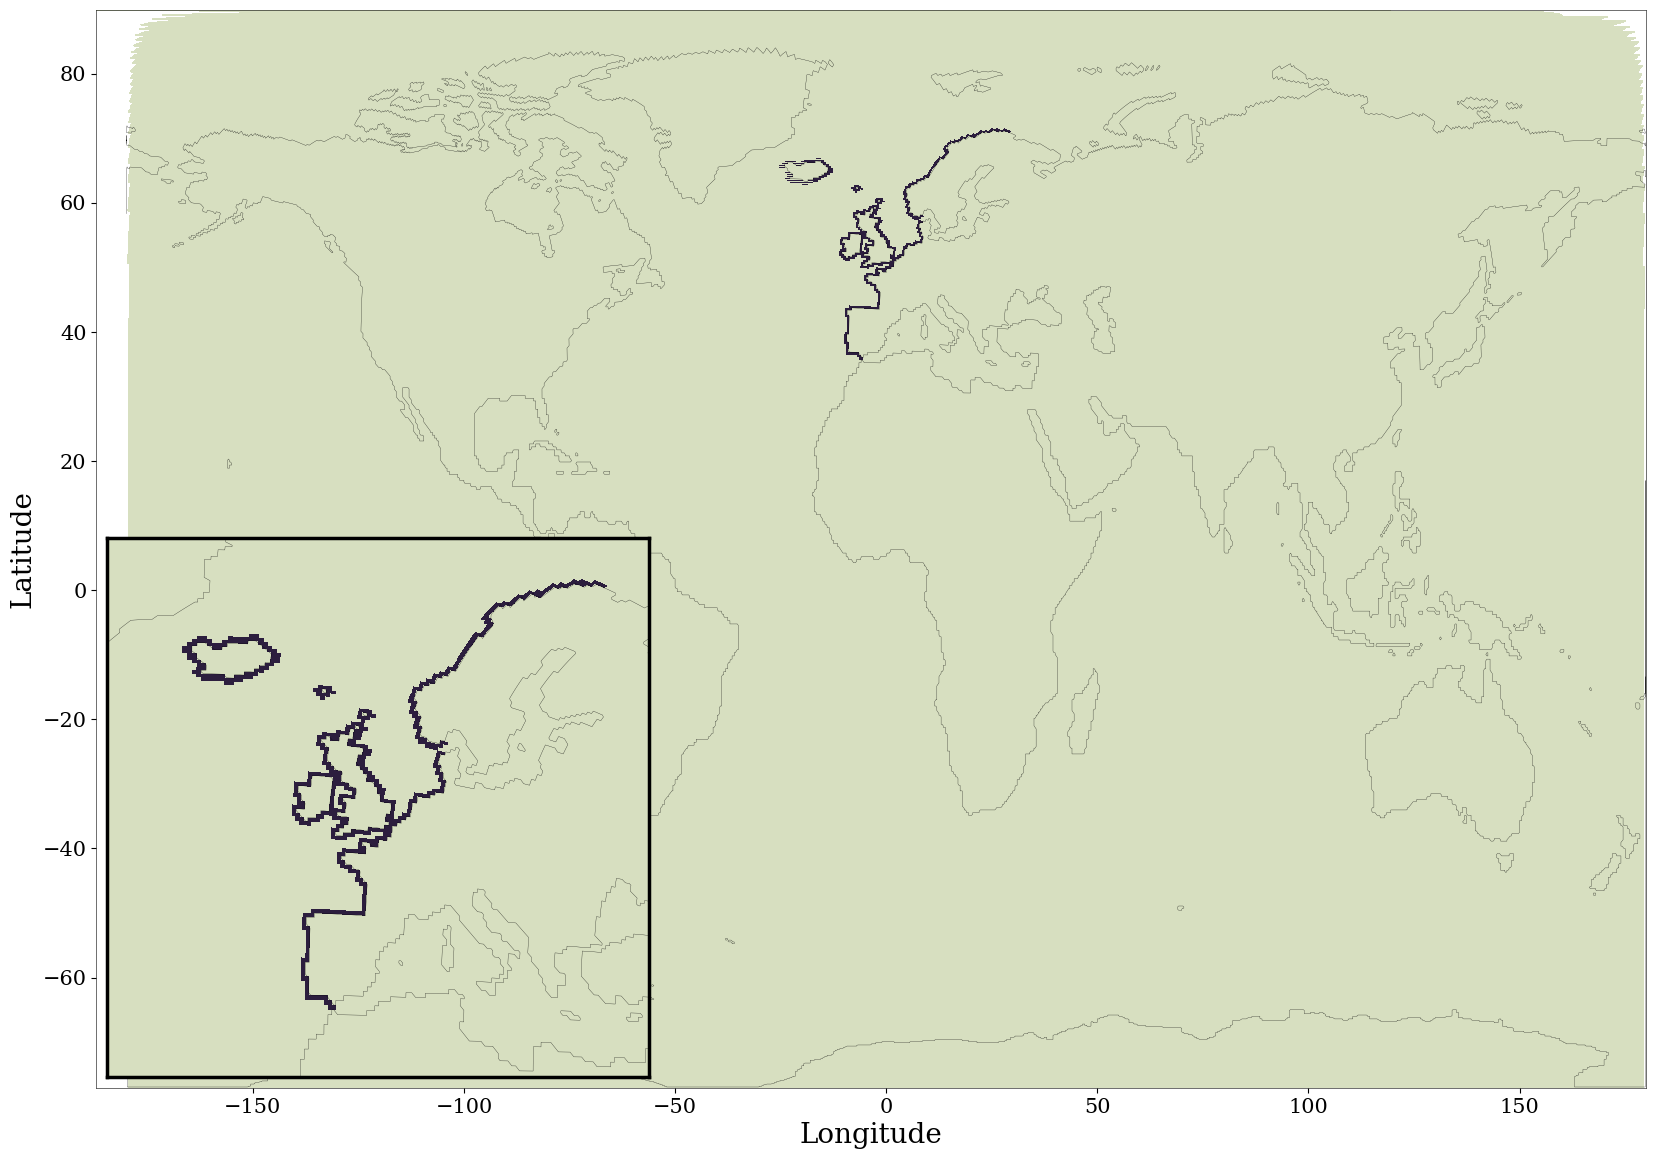

In [132]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(20,14))

alk_mask = xr.open_dataset(data_path + '../alk_mask/alkalinity_mask_timeseries.nc')['alk_flux'].sum('time_counter')
alk_mask = alk_mask.where(alk_mask)
alk_mask = xr.where(alk_mask.notnull(), 1, 0)

mesh_mask = xr.open_dataset(data_path + '/mesh_mask.nc').isel(t=0,z=0)
# mesh_mask = mesh_mask.where(mesh_mask)
# mesh_mask = xr.where(mesh_mask.notnull(), 0, 1)

mesh_mask_sliced = mesh_mask.where((mesh_mask['nav_lon']>-40) & (mesh_mask['nav_lon']<55) & (mesh_mask['nav_lat']>25) & (mesh_mask['nav_lat']<80), drop=True)
alk_mask_sliced = alk_mask.where((alk_mask['nav_lon']>-40) & (alk_mask['nav_lon']<55) & (alk_mask['nav_lat']>25) & (alk_mask['nav_lat']<80), drop=True)

cmap = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)
cmap, norm = create_discrete_cmap(cmap, 20)

lon, lat = 'nav_lon', 'nav_lat'

x = mesh_mask[lon].values.ravel()
y = mesh_mask[lat].values.ravel()
z = mesh_mask['tmask'].values.ravel()

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
ax.tricontour(
    x[mask],
    y[mask],
    z[mask],
    levels=[0.5],
    colors='black',
    linewidths=0.2,
)

ax.pcolormesh(
                    alk_mask[lon],
                    alk_mask[lat],
                    alk_mask,
                    vmin=0,vmax=1,
                    cmap = cmap,
                )

axins = inset_axes(ax, width="35%", height="50%", loc="lower left")

im = axins.pcolormesh(
                    alk_mask_sliced[lon],
                    alk_mask_sliced[lat],
                    alk_mask_sliced,
                    cmap = cmap,
                )

x = mesh_mask_sliced[lon].values.ravel()
y = mesh_mask_sliced[lat].values.ravel()
z = mesh_mask_sliced['tmask'].values.ravel()

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

axins.tricontour(
    x[mask],
    y[mask],
    z[mask],
    levels=[0.5],
    colors='black',
    linewidths=0.2,
)

fineline(ax)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# fineline(axins)

axins.set_xticks([])
axins.set_yticks([])
axins.set_xticklabels([])
axins.set_yticklabels([])
axins.set_xlim(-35,35)
axins.set_ylim(30,75)

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure_1_updated.png')

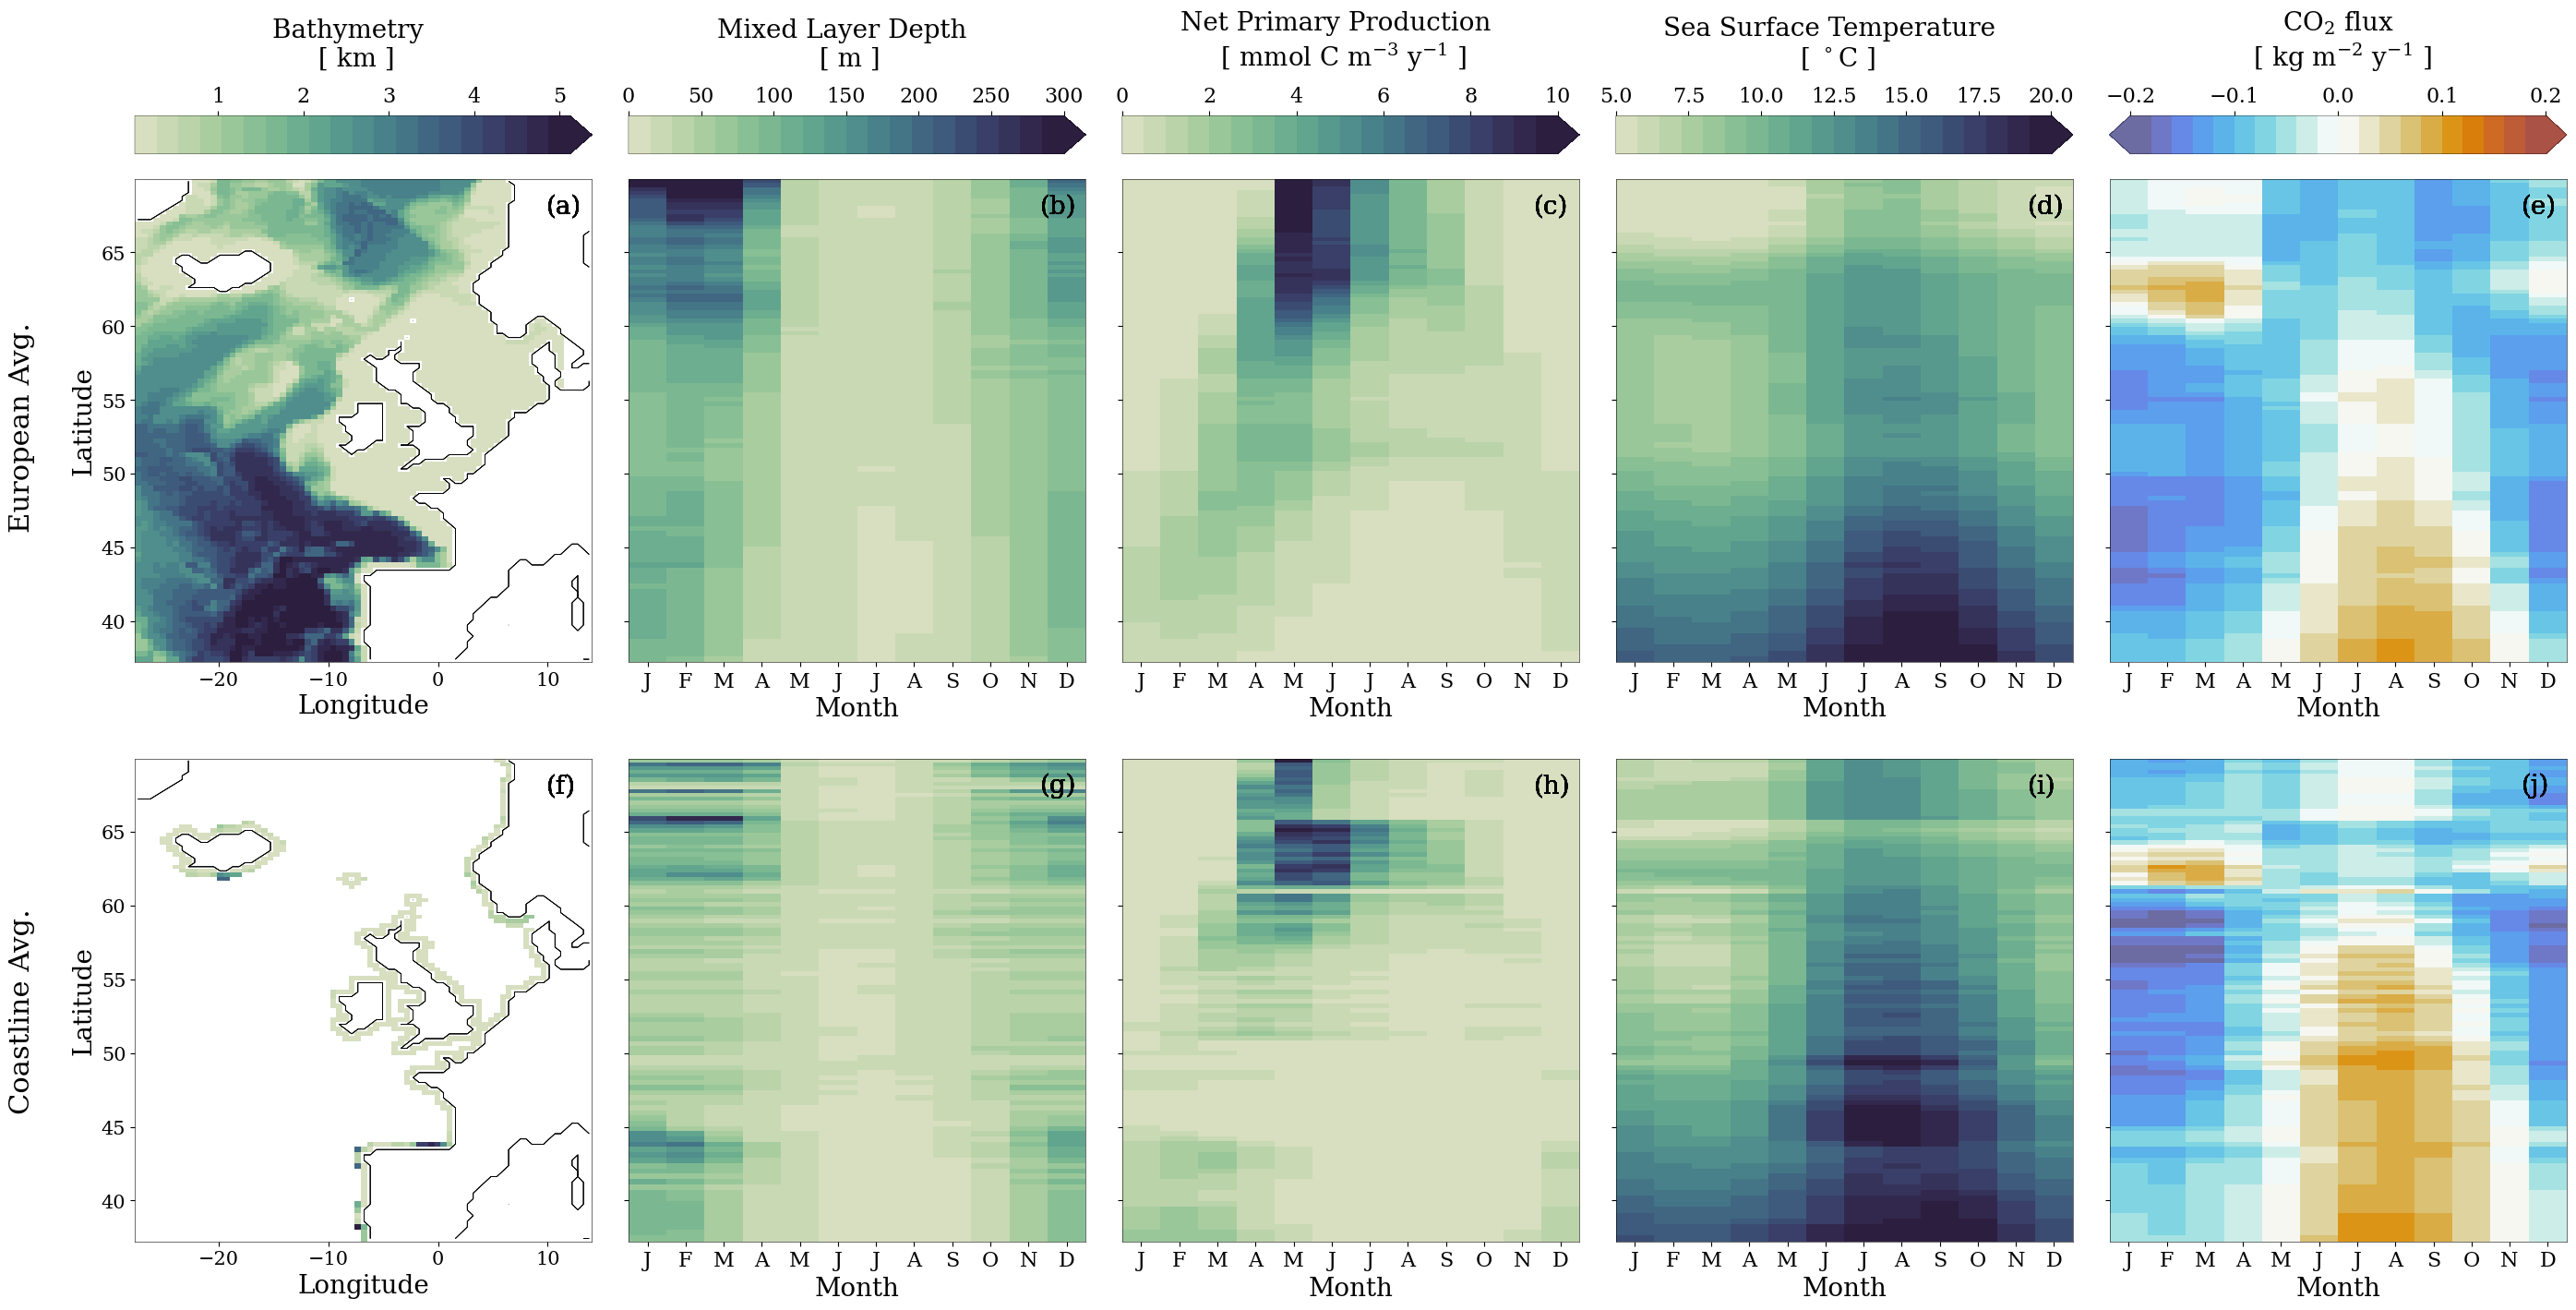

In [11]:
vars = {
    'mld':     {'var_name': 'somxl010'                           , 'vmin':0,'vmax':300,    'unit_chg': 'm', 'long': 'Mixed Layer Depth'},
    'npp':     {'var_name': 'bgc_diag_pp', 'conv_term':'31536000', 'vmin':0,'vmax':10,     'unit_chg': r'mmol C $\mathregular{m^{-3} \ y^{-1}}$', 'long':'Net Primary Production'},
    'sst':     {'var_name': 'sosstsst'                           , 'vmin':5,'vmax':20,     'unit_chg': r'$^\circ$C', 'long': 'Sea Surface Temperature'},
    'co2flux': {'var_name': 'co2flux', 'conv_term':'31536000',     'vmin':-0.2,'vmax':0.2, 'unit_chg': r'kg $\mathregular{m^{-2} \ y^{-1}}$', 'long':'$\mathregular{CO_{2}}$ flux'},
}

fig, axes = plt.subplots(2, (len(vars)+1), figsize=(34, 18),sharey=True)
plt.subplots_adjust(wspace=0.08)

ims = {}
extends = {}    

for j, (var_key, keys) in enumerate(vars.items()):
    
    var = keys['var_name']
    conv_term = eval(keys['conv_term']) if 'conv_term' in keys else 1
    vmin, vmax = keys['vmin'], keys['vmax']
    
    alk_mask = xr.open_dataset(data_path + '../alk_mask/alkalinity_mask_y2035.nc')['alk_flux']
    mesh_mask = xr.open_dataset(data_path + '/mesh_mask.nc').isel(t=0,z=0)
    dic = xr.open_dataset(data_path + f'/dic_baseline_126.nc')
    dic_original = dic.isel(deptht=0,time_counter=0)
    lat_dic, lon_dic = dic['nav_lat'].mean('x'), dic['nav_lon'].mean('y')
    dic = dic.assign_coords(y=lat_dic, x=lon_dic)

    dx, dy = mesh_mask.e1t, mesh_mask.e2t
    grid_cell_area = (dx * dy)

    polygon_boundaries = polygon(mesh_mask)
    mesh_mask = mesh_mask['tmask'] * polygon_boundaries
    
    if var in ['sosstsst','bgc_diag_pp']:
        grid_cell_area = grid_cell_area.sel(x=slice(519, 595), y=slice(329, 435))
        mesh_mask = mesh_mask.sel(x=slice(519, 595), y=slice(329, 435))
        alk_mask = alk_mask.sel(x=slice(519, 595), y=slice(329, 435))   

    else:
        grid_cell_area = grid_cell_area.sel(x=slice(520, 595), y=slice(330, 435))
        mesh_mask = mesh_mask.sel(x=slice(520, 595), y=slice(330, 435))
        alk_mask = alk_mask.sel(x=slice(520, 595), y=slice(330, 435))

        mask_map = depth_mask(dic, 'DIC', 'deptht', mesh_mask)
        alk_map = depth_mask(dic, 'DIC', 'deptht', alk_mask)

    ds_in = xr.open_dataset(data_path + f'/{var_key}_baseline_126.nc')
    lat = ds_in['nav_lat'].mean('x')
    ds_in = ds_in.assign_coords(y=lat)

    if len(ds_in.dims) > 3 and var != 'sosstsst':
        ds_in = ds_in.isel(deptht=0)

    ds_in[var] = ds_in[var] * conv_term

    for i, (mask, map) in enumerate(zip([mesh_mask, alk_mask],[mask_map,alk_map])):
        
        for ax, letter in zip(axes.flat, string.ascii_lowercase):
            ax.text(0.9, 0.93, f"({letter})", transform=ax.transAxes, fontsize=20, font=font_prop)
        
        ax_left = axes[i, 0]
        axes_right = axes[i, j+1]  

        ds_out = ((ds_in[var] * mask * grid_cell_area).sum('x')) / ((mask * grid_cell_area).sum('x'))
    
        ds_out = ds_out.to_dataset(name=var)
        ds_out = monthly_means(ds_out, var)
        
        cmap_dic, extend = discretised_cmap(map)    
        cmap, extend = discretised_cmap(ds_out[var])    

        im_map = ax_left.pcolormesh(lon_dic, lat_dic, map * 1.e-3, cmap=cmap_dic)
        ax_left.contour(lon_dic, lat_dic, dic_original['DIC'], levels=[0.5], colors='black', linewidths=.5)
        
        im = homvoller(ds_out[var], axes_right, vmin, vmax, 'month', 'y', cmap)
    
        fineline(axes_right)
        month_x_labels(axes_right)
    
        axes_right.set_ylabel("")
        axes_right.set_xlabel("Month")
        axes_right.set_title("")
        
        ax_left.set_ylabel("Latitude")
        ax_left.set_xlabel("Longitude")        
        ax_left.set_title("")

        ims[j] = im
        extends[j] = extend
        fineline(axes[i, j])

for j, (var_key, keys) in enumerate(vars.items()):
    col_axes = [axes[0, j+1], axes[1, j+1]]
    c = fig.colorbar(
        ims[j],
        ax=col_axes,
        aspect=12,
        pad=0.02,
        location="top",
        extend=extends[j]
    )

    c.set_label(f"{keys['long']} \n [ {keys['unit_chg']} ]", labelpad=16)
    c.outline.set_linewidth(0.25)
    c.ax.tick_params(labelsize=16)

c_map = fig.colorbar(im_map, ax=[axes[0,0],axes[1,0]], 
        aspect=12,
        pad=0.02,location='top', extend='max')

c_map.set_label('Bathymetry \n [ km ]', labelpad=16)
c_map.outline.set_linewidth(0.25)
c_map.ax.tick_params(labelsize=16)

row_titles = ['European Avg.', 'Coastline Avg.']
for i, title in enumerate(row_titles):
    fig.text(0.085, 0.54 - i * 0.35,title, ha='left', rotation=90, fontsize=22)

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure_2_updated.png')

In [109]:
alk_mask = xr.open_dataset(data_path + '../alk_mask/alkalinity_mask_timeseries.nc')['alk_flux'].sum('time_counter')
# alk_mask = xr.where(alk_mask.notnull(), 1, 0)

mesh_mask = xr.open_dataset(data_path + '/mesh_mask.nc').isel(t=0,z=0)
mesh_mask = mesh_mask.where(mesh_mask)
mesh_mask = mesh_mask['tmask'].where(alk_mask)

# mesh_mask = xr.where(mesh_mask.notnull(), 0, 1)

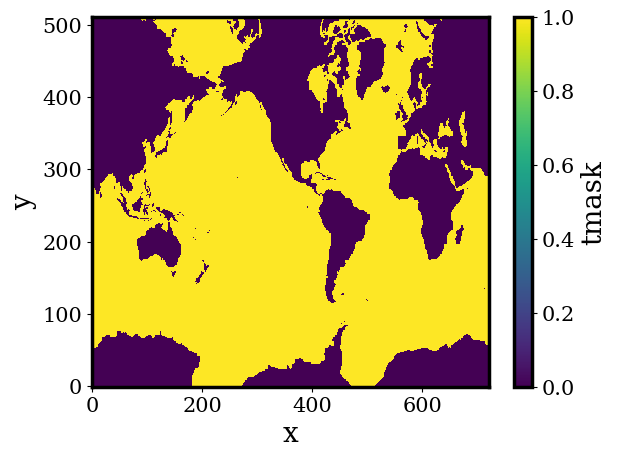

In [113]:
mesh_mask['tmask'].plot()

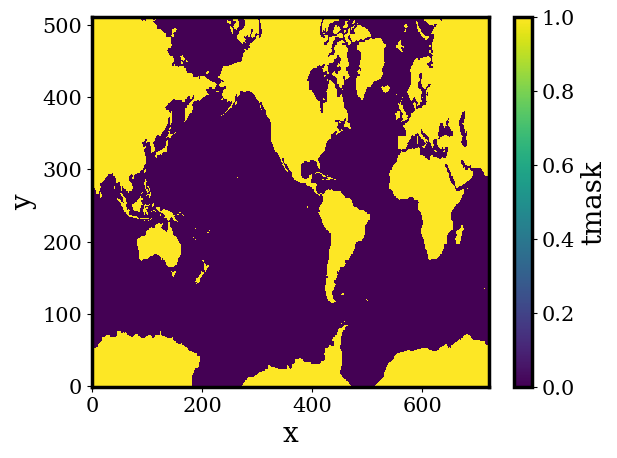

In [119]:
mesh_mask = xr.open_dataset(data_path + '/mesh_mask.nc').isel(t=0,z=0)

xr.where(mesh_mask['tmask']==0, 1, 0).plot()

In [124]:
mesh_mask = xr.open_dataset(data_path + '/mesh_mask.nc').isel(t=0,z=0)
# mesh_mask = mesh_mask.where(mesh_mask)
mesh_mask['tmask'] = xr.where(mesh_mask['tmask']==0, 1, 0)

In [125]:
mesh_mask['tmask']

<xarray.DataArray 'tmask' (y: 511, x: 722)>
array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])
Dimensions without coordinates: y, x